# Quickstart

This guide walks you through creating your first co-simulation with SysSimX.

## Your First Simulation

Let's create a simple system with two components connected in series.

### Import SysSimX

In [1]:
from syssimx import System, Connection
from syssimx.core.base import CoSimComponent
from syssimx.core.port import PortSpec, PortType

### Define a Custom Component 

In [9]:
class Integrator(CoSimComponent):
    """Simple Euler integrator: y = y + u * dt"""

    def __init__(self, name: str, x0: float = 0.0):
        super().__init__(name)
        self.x0 = x0
        self.x = x0

        # Define ports
        self.input_specs = {
            "u": PortSpec(name="u", type=PortType.REAL, direction="in")
        }
        self.output_specs = {
            "y": PortSpec(name="y", type=PortType.REAL, direction="out")
        }

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0

    def _do_step_internal(self, t: float, dt: float) -> None:
        u = self.inputs["u"].get() or 0.0
        self.x = self.x + u * dt

    def _update_output_states(self, t=None, event_names=None) -> None:
        self.outputs["y"].set(self.x, t=t)

In [10]:
class ConstantSource(CoSimComponent):
    """A source component that outputs a constant value."""

    def __init__(self, name: str, value: float = 1.0):
        super().__init__(name)
        self.value = value
        self.output_specs.update({"y": PortSpec(name="y", type=PortType.REAL, direction="out")})
        self.direct_feedthrough = {}  # No inputs, no feedthrough

    def _initialize_component(self, t0: float) -> None:
        pass

    def _do_step_internal(self, t: float, dt: float) -> None:
        pass

    def _update_output_states(self, t: float | None = None, event_names: list[str] | None = None):
        self.outputs["y"].set(self.value, t)

### Build the System

In [11]:
# Create components
source = ConstantSource("Source", value=1.0)
integrator = Integrator("Integrator", x0=0.0)

# Create system
system = System(name="IntegratorDemo")
system.add_component(source)
system.add_component(integrator)

# Connect: Source.y -> Integrator.u
system.add_connection(Connection(
    src_comp="Source", src_port="y",
    dst_comp="Integrator", dst_port="u"
))

### Run the Simulation

In [12]:
# Initialize at t=0
system.initialize(t0=0.0)

# Run for 10 seconds with dt=0.01
system.run(t0=0.0, tf=10.0, dt=0.01)

# Get results
time, data = integrator.get_history_arrays()
print(f"Final value: {data['y'][-1]}")  # Should be ~10.0

Final value: 9.999999999999831


### Visualize Results

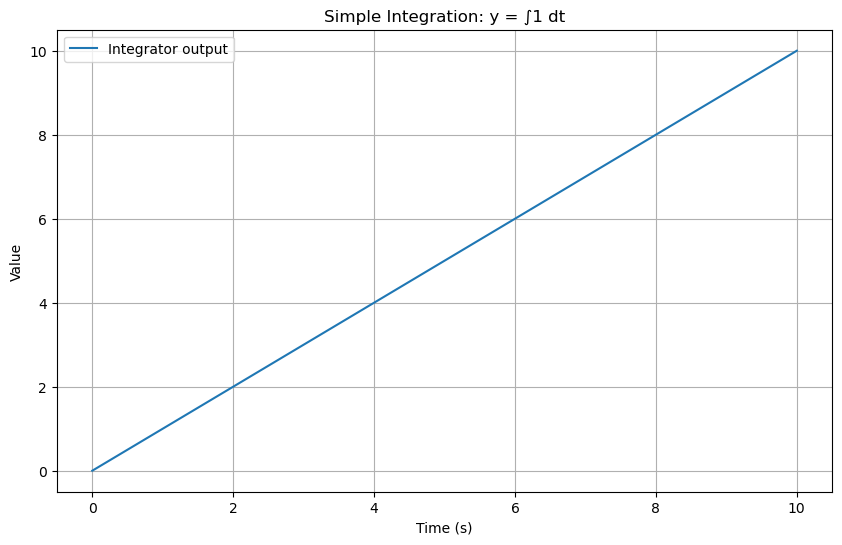

In [13]:
import matplotlib.pyplot as plt

time, data = integrator.get_history_arrays()

plt.figure(figsize=(10, 6))
plt.plot(time, data["y"], label="Integrator output")
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.title("Simple Integration: y = ∫1 dt")
plt.legend()
plt.grid(True)
plt.show()